# OMNI y DONKI — inventario, diccionario y exploración

Este notebook recorre **las dos fuentes de clima espacial que están en disco**
—OMNI (driver continuo) y DONKI (marco de eventos)—, genera el diccionario de
datos **desde los propios Parquet** y las cruza entre sí.

Objetivos:

1. **Inventario**: qué artefactos existen bajo `data/`, con filas, columnas y
   tamaño reales, y qué falta.
2. **Diccionario verificable**: una fila por columna con tipo, nulos, mínimo y
   máximo, contrastada contra `docs/datos_omni.md` §8.
3. **Entender la agregación**: por qué `SYM_H` se agrega con `min` y los
   canales de protones con `max`, visto hora a hora en una tormenta real.
4. **Cruzar las dos fuentes**: para cada tormenta `GST` de DONKI, el mínimo de
   `SYM_H` en OMNI. Esto valida empíricamente la definición de tormenta del
   README §3.2.
5. **Probar el tiempo de aviso**: estimar la hora de llegada del shock desde
   la velocidad del CME y compararla con el inicio real de la tormenta, usando
   la cadena causal de DONKI frente a un naive emparejamemiento temporal (§7).
6. **Documentar los huecos y trampas** que van a morder al que use estos datos
   después (§5).

> **Requiere el symlink `data/` montado.** `data/` apunta a la partición
> NTFS de Windows; si no está montada, el symlink queda roto y este notebook
> falla en la celda 1. Ver AGENTS.md §Layout.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)


def find_root(start=Path.cwd()):
    # Sube hasta la raiz del repo.
    # Necesario porque nbconvert ejecuta el kernel con CWD = notebooks/,
    # no en la raiz: un Path("data") relativo no resolveria.
    for candidate in (start, *start.parents):
        if (candidate / "scripts").is_dir() and (candidate / "docs").is_dir():
            return candidate
    raise RuntimeError(f"No se encontro la raiz del repo desde {start}")


ROOT = find_root()
DATA = ROOT / "data"
DOCS = ROOT / "docs"


def year_of(partfile):
    # Particiones estilo data/omni/year=2012/part-00000.parquet
    # Ojo: Path.split() parte componentes de ruta, no el string.
    return int(partfile.parent.name.split("=")[1])


np.set_printoptions(precision=2, suppress=True)

print("pandas", pd.__version__)
print("ROOT       :", ROOT)
print("DATA       :", DATA, "| symlink:", DATA.is_symlink())
print("DATA existe:", DATA.exists())

pandas 3.0.6
ROOT       : /home/pxtron/Documents/cme-sentinel
DATA       : /home/pxtron/Documents/cme-sentinel/data | symlink: True
DATA existe: True


---

## 1. Inventario: qué data hay en disco

Cada artefacto se mide de verdad: se leen los Parquet, se cuentan filas y
columnas, y se toma el tamaño en disco.

In [2]:
def describe_parquet(path):
    df = pd.read_parquet(path)
    return {
        "path": str(path),
        "filas": len(df),
        "cols": df.shape[1],
        "MB": path.stat().st_size / 1e6,
        "modificado": pd.Timestamp(path.stat().st_mtime, tz="UTC").strftime("%Y-%m-%d %H:%M"),
    }


omni_files = sorted(DATA.glob("omni/year=*/part-00000.parquet"))
donki_files = sorted(DATA.glob("donki/*/year=*/part-00000.parquet"))
gunter_files = sorted(DATA.glob("gunter/*.parquet")) + sorted(DATA.glob("gunter/meta/*.parquet"))

rows = [describe_parquet(f) for f in omni_files + gunter_files]
inv = pd.DataFrame(rows)
print(f"OMNI: {len(omni_files)} particiones | DONKI: {len(donki_files)} particiones")
inv

OMNI: 15 particiones | DONKI: 103 particiones


,path,filas,cols,MB,modificado
0,/home/pxtron/Documents/cme-sentinel/data/omni/...,8784,46,1.428504,1970-01-01 00:00
1,/home/pxtron/Documents/cme-sentinel/data/omni/...,8760,46,1.414647,1970-01-01 00:00
2,/home/pxtron/Documents/cme-sentinel/data/omni/...,8760,46,1.396903,1970-01-01 00:00
3,/home/pxtron/Documents/cme-sentinel/data/omni/...,8760,46,1.427496,1970-01-01 00:00
4,/home/pxtron/Documents/cme-sentinel/data/omni/...,8784,46,1.418616,1970-01-01 00:00
5,/home/pxtron/Documents/cme-sentinel/data/omni/...,8760,46,1.404968,1970-01-01 00:00
6,/home/pxtron/Documents/cme-sentinel/data/omni/...,8760,46,1.370201,1970-01-01 00:00
7,/home/pxtron/Documents/cme-sentinel/data/omni/...,8760,46,1.358351,1970-01-01 00:00
8,/home/pxtron/Documents/cme-sentinel/data/omni/...,8784,46,1.350526,1970-01-01 00:00
9,/home/pxtron/Documents/cme-sentinel/data/omni/...,8760,46,1.350184,1970-01-01 00:00


DONKI se particiona por **endpoint** además de por año, así que el inventario
se lee en bloque: 7 endpoints × 15 años.

In [3]:
dk_rows = []
for ep_dir in sorted(DATA.glob("donki/*")):
    files = sorted(ep_dir.glob("year=*/part-00000.parquet"))
    total = 0
    for f in files:
        total += len(pd.read_parquet(f, columns=["source_endpoint"]))
    dk_rows.append(
        {
            "endpoint": ep_dir.name,
            "años": len(files),
            "primer_año": min(year_of(f) for f in files),
            "último_año": max(year_of(f) for f in files),
            "filas": total,
            "MB": sum(f.stat().st_size for f in files) / 1e6,
        }
)
dk = pd.DataFrame(dk_rows).set_index("endpoint")
print(f"TOTAL DONKI: {dk.filas.sum():,} filas en {len(donki_files)} particiones, {dk.MB.sum():.1f} MB")
dk

TOTAL DONKI: 24,610 filas en 103 particiones, 6.4 MB


,años,primer_año,último_año,filas,MB
endpoint,,,,,
CME,15,2012,2026,9951,3.837738
CMEAnalysis,15,2012,2026,8643,1.110384
FLR,15,2012,2026,3347,0.546489
GST,15,2012,2026,186,0.235996
HSS,15,2012,2026,778,0.200388
IPS,15,2012,2026,1237,0.282878
SEP,13,2012,2026,468,0.196768


`gp_history` (Stage 0) **no está en disco** — se borró para liberar espacio.
`notebooks/01_validate_and_explore.ipynb` lo lee, así que ese notebook no
corre hoy. Es el único hueco grande del pipeline.

In [4]:
gp = DATA / "gp_history"
print("gp_history existe:", gp.exists())
print("-> notebooks/01_validate_and_explore.ipynb requiere ese path y hoy falla.")

gp_history existe: False
-> notebooks/01_validate_and_explore.ipynb requiere ese path y hoy falla.


---

## 2. OMNI — driver continuo (NASA SPDF / CDAWeb HAPI)

Una fila por hora, 2012→2026. Diccionario completo en
[`docs/datos_omni.md`](../docs/datos_omni.md); el detalle de la agregación
5 min → 1 h está en su §4.

In [5]:
omni = pd.concat(
    [pd.read_parquet(f) for f in omni_files], ignore_index=True
)
omni = omni.set_index("EPOCH").sort_index()

print("filas:", len(omni), "| columnas:", omni.shape[1])
print("rango:", omni.index.min(), "->", omni.index.max())
print("dtypes no-numericos:", {c: str(t) for c, t in omni.dtypes.items() if t.kind not in "if"})
print("columnas de partición:", [c for c in omni.columns if c == "year"])

filas: 128617 | columnas: 45
rango: 2012-01-01 00:00:00+00:00 -> 2026-09-03 00:00:00+00:00
dtypes no-numericos: {}
columnas de partición: ['year']


### 2.1 Cobertura por año

Cada año debería tener 8760 horas, o 8784 si es bisiesto. Sirve para detectar
años truncados sin mirar el reloj.

In [6]:
cov = (
    omni.groupby(omni.index.year)
    .agg(filas=("SYM_H", "size"), sym_h_min=("SYM_H", "min"), ae_max=("AE_INDEX_max", "max"))
    .rename_axis("year")
)
cov["horas_esperadas"] = [
    8784 if y % 4 == 0 else 8760 for y in cov.index
]
cov["completo"] = cov.filas == cov.horas_esperadas
cov

,filas,sym_h_min,ae_max,horas_esperadas,completo
year,,,,,
2012,8784,-149.0,2241.0,8784,True
2013,8760,-134.0,2413.0,8760,True
2014,8760,-125.0,1725.0,8760,True
2015,8760,-233.0,2471.0,8760,True
2016,8784,-117.0,2185.0,8784,True
2017,8760,-144.0,2351.0,8760,True
2018,8760,-205.0,2020.0,8760,True
2019,8760,-77.0,2034.0,8760,True
2020,8784,-68.0,1652.0,8784,True


### 2.2 Calidad del eje temporal y de los centinelas

`docs/datos_omni.md` §5: los fills de `OMNI_HRO_5MIN` son centinelas
pequeños por parámetro (99999 en `SYM_H`, 99.99 en `Pressure`…), no `-1e31`.
El collector ya los convirtió a `NaN`; lo que queda son gaps reales de L1.

In [7]:
deltas = omni.index.to_series().diff().dropna()
print("timestamps duplicados:", int(omni.index.duplicated().sum()))
print("saltos distintos entre horas consecutivas:", sorted(deltas.unique()))
print("separacion maxima:", deltas.max())
print()
fills = {"SYM_H": 99999.0, "Pressure": 99.99, "flow_speed": 99999.9, "AE_INDEX": 99999.0}
for col, fill in fills.items():
    real = omni[col] if col in omni.columns else None
    if real is not None:
        print(f"{col:14s} fill={fill:<12g} quedan valores >= fill: {int((real.abs() >= fill).sum())}")
print()
print("nulos por columna (top 8):")
print(omni.isna().mean().sort_values(ascending=False).head(8).round(4).to_string())

timestamps duplicados: 0
saltos distintos entre horas consecutivas: [Timedelta('0 days 01:00:00')]
separacion maxima: 0 days 01:00:00

SYM_H          fill=99999        quedan valores >= fill: 0
Pressure       fill=99.99        quedan valores >= fill: 0
flow_speed     fill=99999.9      quedan valores >= fill: 0

nulos por columna (top 8):
PR-FLX_10_max     0.4462
PR-FLX_30_max     0.4462
PR-FLX_60_max     0.4462
PC_N_INDEX_max    0.1159
Mgs_mach_num      0.0320
Beta              0.0320
T                 0.0319
E                 0.0318


### 2.3 Diccionario generado desde la data

Acá **no** se transcribe el diccionario: se calcula. Una fila por columna con
tipo, nulos, mínimo, máximo y un ejemplo, para poder leer la forma real del
dataset sin abrir el Parquet.

In [8]:
stats = pd.DataFrame(
    {
        "tipo": omni.dtypes.astype(str),
        "nulos_%": (omni.isna().mean() * 100).round(2),
        "min": omni.min(numeric_only=True).round(3),
        "max": omni.max(numeric_only=True).round(3),
    }
)
stats["ejemplo"] = [str(omni[c].dropna().iloc[0])[:18] if omni[c].notna().any() else "" for c in omni.columns]
stats

,tipo,nulos_%,min,max,ejemplo
IMF,float64,3.09,51.000,71.000,71.0
PLS,float64,3.18,51.000,71.000,71.0
IMF_PTS,float64,3.09,1.000,5.000,4.833333333333333
PLS_PTS,float64,3.18,1.000,5.000,4.166666666666667
percent_interp,float64,3.09,0.000,100.000,39.583333333333336
Timeshift,float64,3.09,-6589.833,10729.000,3094.25
RMS_Timeshift,float64,3.09,0.000,2200.250,176.25
Time_btwn_obs,float64,3.11,-1391.091,2637.800,79.91666666666667
F,float64,3.09,0.491,69.122,4.246666666666667
BX_GSE,float64,3.09,-41.977,28.289,3.3241666666666667


#### Contraste contra `docs/datos_omni.md` §8

El doc es la fuente de verdad escrita; esta celda verifica que **toda columna
de la data esté documentada**. Si alguien agrega un parámetro al collector y
no actualiza el doc, salta acá.

In [9]:
import re

doc = (DOCS / "datos_omni.md").read_text(encoding="utf-8")
seccion = doc.split("## 8. Diccionario de columnas", 1)[1].split("## 9.", 1)[0]


def columnas_de_token(tok):
    # El doc agrupa columnas en una fila con "/", de dos formas:
    #   `Vx/Vy/Vz`   -> partes completas
    #   `BSN_x/y/z`  -> prefijo compartido ("BSN_" + y + z)
    # Normalizar las dos evita que el chequeo marque columnas ya documentadas.
    partes = [p.strip() for p in tok.replace("*", "").split("/") if p.strip()]
    if len(partes) == 1:
        return partes
    prefijo = partes[0].rsplit("_", 1)[0] + "_" if "_" in partes[0] else partes[0][:-1]
    out = list(partes)
    for p in partes[1:]:
        if prefijo and not p.startswith(prefijo):
            out.append(prefijo + p)
    return out


documentadas = set()
for tok in re.findall(r"`([^`]+)`", seccion):
    documentadas.update(columnas_de_token(tok))

sin_doc = sorted(set(omni.columns) - documentadas)
print(f"columnas en la data        : {len(omni.columns)}")
print(f"documentadas en datos_omni  : {len(set(omni.columns) & documentadas)}")
print(f"sin documentar              : {sin_doc or 'ninguna'}")
assert not sin_doc, f"columnas sin documentar en datos_omni.md: {sin_doc}"
print("OK: el doc cubre todas las columnas de la data.")

columnas en la data        : 45
documentadas en datos_omni  : 45
sin documentar              : ninguna
OK: el doc cubre todas las columnas de la data.


Chequeos numéricos de control. Son los valores conocidos que
`docs/datos_omni.md` §7 declara haber validado; si el collector o el host
cambian de comportamiento, se mueven.

In [10]:
checks = {
    "SYM_H": (-497.0, 69.0, 0.5),
    "AE_INDEX_max": (6.0, 3997.0, 0.5),
    "flow_speed": (250.0, 1075.0, 1.0),
    "PR-FLX_10_max": (0.0, 5656.0, 1.0),
}
for col, (lo, hi, tol) in checks.items():
    vmin, vmax = omni[col].min(), omni[col].max()
    assert abs(vmin - lo) < tol, f"{col} min {vmin} != {lo}"
    assert abs(vmax - hi) < tol, f"{col} max {vmax} != {hi}"
    print(f"OK {col:14s} min={vmin:>10.2f}  max={vmax:>10.2f}")
print()
print("nulos PR-FLX_10_max: %.2f%%  (doc §8: 44.6%%)" % (omni["PR-FLX_10_max"].isna().mean() * 100))

OK SYM_H          min=   -497.00  max=     69.00
OK AE_INDEX_max   min=      6.00  max=   3997.00
OK flow_speed     min=    250.22  max=   1074.62
OK PR-FLX_10_max  min=      0.09  max=   5655.10

nulos PR-FLX_10_max: 44.62%  (doc §8: 44.6%)


### 2.4 Por qué la agregación 5 min → hora no es un `mean`

`docs/datos_omni.md` §4: `min` para los índices de corriente en anillo
(el mínimo **es** la profundidad de la tormenta) y `max` para los canales de
protones (el pico **es** la severidad del evento). El promedio hides el
extremo. La tormenta de San Patricio (2015-03-17, la más intensa del mínimo
solar 24) hora a hora:

In [11]:
storm_day = omni.loc["2015-03-17 06:00":"2015-03-17 23:00",
                     ["SYM_H", "SYM_D", "AE_INDEX_max", "flow_speed", "Pressure"]]
print(storm_day.to_string())
print()
print(f"SYM_H  min de la ventana = {storm_day.SYM_H.min():.1f} nT   <- profundidad real")
print(f"SYM_H  mean de la ventana = {storm_day.SYM_H.mean():.1f} nT  <- lo que daría el promedio")
print(f"subestimacion del promedio: {storm_day.SYM_H.mean() - storm_day.SYM_H.min():.1f} nT "
      f"({(1 - storm_day.SYM_H.mean() / storm_day.SYM_H.min()) * 100:.0f}% del minimo)")

                           SYM_H  SYM_D  AE_INDEX_max  flow_speed   Pressure
EPOCH                                                                       
2015-03-17 06:00:00+00:00   -3.0   -3.0         741.0  518.300000  16.971667
2015-03-17 07:00:00+00:00  -35.0    3.0         822.0  517.550000  13.193333
2015-03-17 08:00:00+00:00  -73.0    6.0         981.0  558.566667  12.507778
2015-03-17 09:00:00+00:00  -99.0   -2.0         858.0  555.437500  15.630000
2015-03-17 10:00:00+00:00  -83.0    4.0         475.0  562.909091  14.630000
2015-03-17 11:00:00+00:00  -59.0    2.0         263.0  611.291667  19.305000
2015-03-17 12:00:00+00:00  -76.0    2.0         529.0  597.033333  12.250833
2015-03-17 13:00:00+00:00  -93.0   -7.0        2046.0  584.858333  18.164167
2015-03-17 14:00:00+00:00  -99.0   -6.0        1913.0  588.345455  15.705455
2015-03-17 15:00:00+00:00 -143.0    6.0        1446.0  607.820000  17.786000
2015-03-17 16:00:00+00:00 -157.0   -5.0        1619.0  612.341667  14.235000

Si se hubiera guardado el promedio horario, la profundidad de esa tormenta
quedaría registrada como −125 nT en lugar de −233 nT: casi la mitad. Con el
`min` el umbral `SYM_H ≤ −50 nT` del README §3.2 corta donde debe.

### 2.5 Las horas de tormenta, por año

In [12]:
por_anio = pd.DataFrame(
    {
        "horas_SYM_H<=-50": omni.groupby(omni.index.year).apply(lambda g: int((g.SYM_H <= -50).sum())),
        "horas_AE>=1000": omni.groupby(omni.index.year).apply(lambda g: int((g.AE_INDEX_max >= 1000).sum())),
    }
)
por_anio["cualquiera"] = omni.groupby(omni.index.year).apply(
    lambda g: int(((g.SYM_H <= -50) | (g.AE_INDEX_max >= 1000)).sum())
)
print("2015 (minimo solar 24) y 2024-25 (maximo solar 25) concentran las tormentas:")
por_anio

2015 (minimo solar 24) y 2024-25 (maximo solar 25) concentran las tormentas:


,horas_SYM_H<=-50,horas_AE>=1000,cualquiera
EPOCH,,,
2012,427,200,499
2013,275,154,338
2014,165,80,217
2015,672,298,785
2016,304,229,447
2017,188,220,339
2018,95,93,156
2019,41,76,99
2020,31,42,66


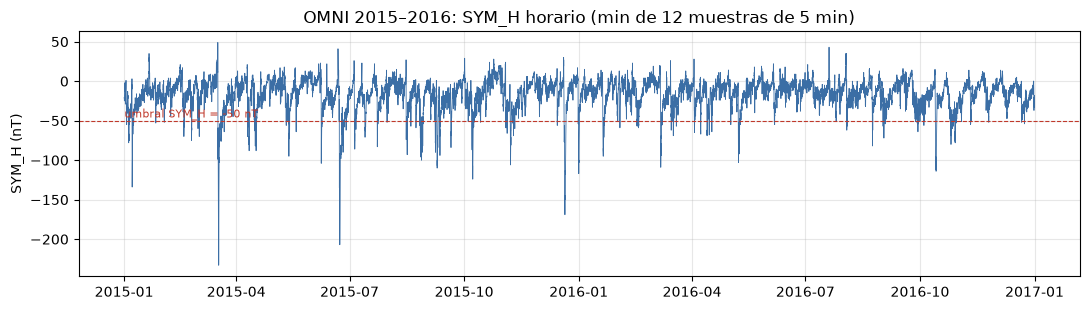

In [13]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(omni.loc["2015": "2016"].index, omni.loc["2015":"2016"]["SYM_H"], lw=0.6, color="#3b6ea5")
ax.axhline(-50, ls="--", lw=0.8, color="#c0392b")
ax.text(omni.loc["2015":"2016"].index[5], -46, "umbral SYM_H = -50 nT", color="#c0392b", fontsize=8)
ax.set_ylabel("SYM_H (nT)")
ax.set_title("OMNI 2015–2016: SYM_H horario (min de 12 muestras de 5 min)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 2.6 Los canales de protones: 44,6% de nulos no son ceros

`PR-FLX_*` viene con ~45% de nulos. **Nulo significa "sin dato de evento"**,
no "flujo cero": la respuesta del instrumento no llegó. Interpretarlos como
cero desviaría hacia abajo cualquier análisis de SEP.

In [14]:
pf = omni[["PR-FLX_10_max", "PR-FLX_30_max", "PR-FLX_60_max"]]
print("nulos por canal:")
print((pf.isna().mean() * 100).round(2).to_string())
print()
presente = pf.dropna()
print(f"horas con dato de protones: {len(presente):,} de {len(omni):,}")
print(f"minimo observado (no cero): {presente.min().min():.3f} pfu")
print(f"horas con PR-FLX_10 > 10 pfu: {int((presente['PR-FLX_10_max'] > 10).sum())}")
print()
print("Ningun canal vale 0.0 exacto -> confirma que los nulos son ausencias,")
print("no lecturas de flujo nulo.")

nulos por canal:
PR-FLX_10_max    44.62
PR-FLX_30_max    44.62
PR-FLX_60_max    44.62

horas con dato de protones: 71,224 de 128,617
minimo observado (no cero): 0.030 pfu
horas con PR-FLX_10 > 10 pfu: 1387

Ningun canal vale 0.0 exacto -> confirma que los nulos son ausencias,
no lecturas de flujo nulo.


---

## 3. DONKI — marco de eventos (NASA CCMC)

Siete endpoints, una fila por evento discreto, con estructuras anidadas
(`linkedEvents`, `allKpIndex`, `cmeAnalyses`, `instruments`) aplanadas por
`scripts/fetch_donki.py`. Diccionario completo en
[`docs/datos_donki.md`](../docs/datos_donki.md).

In [15]:
DONKI = {
    ep: pd.concat(
        [pd.read_parquet(f) for f in sorted(DATA.glob(f"donki/{ep}/year=*/part-00000.parquet"))],
        ignore_index=True,
    )
    for ep in ["CME", "CMEAnalysis", "GST", "FLR", "SEP", "IPS", "HSS"]
    if list(DATA.glob(f"donki/{ep}/year=*/part-00000.parquet"))
}
for ep, d in DONKI.items():
    print(f"{ep:13s} {len(d):6,d} filas  {d.shape[1]:2d} cols")
print(f"{'TOTAL':13s} {sum(len(d) for d in DONKI.values()):6,d} filas")

CME            9,951 filas  21 cols
CMEAnalysis    8,643 filas  24 cols
GST              186 filas  16 cols
FLR            3,347 filas  22 cols
SEP              468 filas  15 cols
IPS            1,237 filas  17 cols
HSS              778 filas  14 cols
TOTAL         24,610 filas


### 3.1 Matriz endpoint × año

Las celdas `-` son años que DONKI devuelve vacíos.

In [16]:
years = range(2012, 2027)


def time_col(d):
    return next(c for c in d.columns if c in ("startTime", "eventTime", "beginTime", "time21_5"))


matriz = {}
for ep, d in DONKI.items():
    t = pd.to_datetime(d[time_col(d)], utc=True, format="mixed")
    matriz[ep] = {y: int((t.dt.year == y).sum()) for y in years}
matriz = pd.DataFrame(matriz)
matriz.index.name = "año"
print("eventos por año y endpoint; '-' = año que DONKI devuelve vacío")
matriz.T.replace(0, "-")

eventos por año y endpoint; '-' = año que DONKI devuelve vacío


año,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
CME,354,357,691,523,333,222,51,66,143,510,1018,1241,1512,1655,1275
CMEAnalysis,361,359,632,449,304,210,51,65,124,437,896,1047,1319,1408,981
GST,13,6,6,27,19,14,7,3,1,5,10,16,20,24,15
FLR,33,28,221,152,27,67,4,7,7,101,304,479,1128,464,325
SEP,41,31,27,10,2,13,-,-,2,13,40,75,119,60,35
IPS,137,120,140,40,28,19,7,15,16,89,139,149,130,116,92
HSS,13,9,29,34,37,83,83,74,35,73,77,58,33,85,55


> ⚠️ `SEP` 2018 y 2019 están vacíos. **No es un fallo del collector**: se
> verificó contra la API cruda de DONKI y devuelve 0 eventos para ambos años
> (2017→13, 2020→2). Es un hueco del catálogo. El collector los marca como
> completados en `data/.progress.json` sin escribir Parquet, así que un
> `--reset` no los va a rellenar nunca.

### 3.2 Diccionario por endpoint

El collector aplana cada registro de DONKI: las listas se vuelven
`<campo>_count` + el JSON serializado, y tres listas reciben además
extracciones globales.

In [17]:
EXTRACCIONES = {
    "linked_activity_ids": "lista de activityID enlazados (cadenas causales)",
    "all_kp_max": "maximo de kpIndex del array allKpIndex (solo GST)",
    "all_kp_times": "marcas de tiempo de cada kpIndex (solo GST)",
    "instruments_displayName": "displayName de cada instrumento",
}
COMUNES = {
    "source_endpoint": "endpoint de origen (constante)",
    "fetched_at": "momento de la descarga (auditoria)",
    "submissionTime": "cuando DONKI recibio el reporte",
    "versionId": "version del registro en DONKI",
    "link": "URL del evento en webtools CCMC",
}
for ep, d in DONKI.items():
    print("=" * 70)
    print(f"{ep}  ({len(d):,} filas, {d.shape[1]} columnas)")
    print("=" * 70)
    for c in d.columns:
        if c in EXTRACCIONES or c in COMUNES:
            continue
        nn = d[c].isna().mean() * 100
        ex = str(d[c].dropna().iloc[0])[:52] if d[c].notna().any() else ""
        print(f"  {c:26s} {str(d[c].dtype):17s} nulos={nn:5.1f}%  {ex}")
    for c, desc in {**COMUNES, **EXTRACCIONES}.items():
        if c in d.columns:
            print(f"  {c:26s} {'':17s} {'(derivada)' if c in EXTRACCIONES else '(metadato)':12s} {desc}")

CME  (9,951 filas, 21 columnas)
  activityID                 str               nulos=  0.0%  2012-01-01T13:36:00-CME-001
  catalog                    str               nulos=  0.0%  M2M_CATALOG
  startTime                  str               nulos=  0.0%  2012-01-01T13:36Z
  instruments_count          int64             nulos=  0.0%  3
  instruments                str               nulos=  0.0%  [{"displayName": "STEREO A: SECCHI/COR2"}, {"display
  sourceLocation             str               nulos=  0.0%  
  activeRegionNum            float64           nulos= 79.7%  11401.0
  note                       str               nulos=  0.0%  
  cmeAnalyses_count          int64             nulos=  0.0%  1
  cmeAnalyses                str               nulos=  0.0%  [{"isMostAccurate": true, "time21_5": "2012-01-01T18
  linkedEvents_count         float64           nulos= 81.5%  1.0
  linkedEvents               str               nulos= 81.5%  [{"activityID": "2012-01-02T18:28:00-IPS-001"}]
  sent

### 3.3 Las cadenas causales: `linkedEvents`

DONKI enlaza eventos entre endpoints por `activityID`. Eso es lo que
convierte la tabla en un **marco de eventos**: un CME que produce un IPS, que
produce un SEP, que dispara un GST. El grafo se puede recorrer join por join.

In [18]:
ej = DONKI["GST"].nlargest(3, "all_kp_max")[["gstID", "startTime", "all_kp_max", "linked_activity_ids"]]
for _, r in ej.iterrows():
    print(f"{r.gstID}  Kp_max={r.all_kp_max}")
    print(f"  start        {r.startTime}")
    for lid in r.linked_activity_ids:
        tipo = lid.split("-")[-2]
        print(f"  -> {tipo:4s} {lid}")
    print()

2024-05-10T15:00:00-GST-001  Kp_max=9.0
  start        2024-05-10T15:00Z
  -> CME  2024-05-08T05:36:00-CME-001
  -> CME  2024-05-08T12:24:00-CME-001
  -> CME  2024-05-08T19:12:00-CME-001
  -> CME  2024-05-08T22:24:00-CME-001
  -> CME  2024-05-09T09:24:00-CME-001
  -> IPS  2024-05-10T16:36:00-IPS-001

2024-10-10T15:00:00-GST-001  Kp_max=8.67
  start        2024-10-10T15:00Z
  -> CME  2024-10-09T02:12:00-CME-001
  -> IPS  2024-10-10T14:46:00-IPS-001
  -> MPC  2024-10-10T17:13:00-MPC-001

2025-11-12T00:00:00-GST-001  Kp_max=8.67
  start        2025-11-12T00:00Z
  -> CME  2025-11-07T12:53:00-CME-001
  -> CME  2025-11-09T07:24:00-CME-001
  -> CME  2025-11-10T09:36:00-CME-001
  -> IPS  2025-11-11T22:11:00-IPS-001
  -> MPC  2025-11-12T00:59:00-MPC-001



La cadena del 2024-05-10 (la tormenta Gannon, la más fuerte en 20 años)
atraviesa los cuatro endpoints. Esto es exactamente el eslabón
`CME → tormenta → drag` que busca el proyecto.

In [19]:
cadena = "2024-05-10"
for ep in ["CME", "SEP", "FLR", "GST"]:
    d = DONKI[ep].copy()
    tcol = next(c for c in d.columns if c in ("startTime", "eventTime", "beginTime", "time21_5"))
    d["t"] = pd.to_datetime(d[tcol], utc=True, format="mixed")
    sub = d[d.t.dt.strftime("%Y-%m-%d").str.startswith(cadena)]
    if sub.empty:
        print(f"{ep:4s} sin eventos el {cadena}")
        continue
    idc = {"CME": "activityID", "SEP": "sepID", "FLR": "flrID", "GST": "gstID"}[ep]
    kp = f"  Kp_max={sub['all_kp_max'].max():.2f}" if "all_kp_max" in sub else ""
    print(f"{ep:4s} {len(sub):3d} evento(s){kp}")
    for _, r in sub.head(4).iterrows():
        print(f"       {r[idc]}  {r[tcol]}")

CME    6 evento(s)
       2024-05-10T02:12:00-CME-001  2024-05-10T02:12Z
       2024-05-10T07:12:00-CME-001  2024-05-10T07:12Z
       2024-05-10T16:36:00-CME-001  2024-05-10T16:36Z
       2024-05-10T21:17:00-CME-001  2024-05-10T21:17Z
SEP    4 evento(s)
       2024-05-10T12:59:00-SEP-001  2024-05-10T12:59Z
       2024-05-10T13:02:00-SEP-001  2024-05-10T13:02Z
       2024-05-10T13:35:00-SEP-001  2024-05-10T13:35Z
       2024-05-10T14:50:00-SEP-001  2024-05-10T14:50Z


FLR   15 evento(s)
       2024-05-10T00:10:00-FLR-001  2024-05-10T00:10Z
       2024-05-10T03:15:00-FLR-001  2024-05-10T03:15Z
       2024-05-10T06:14:00-FLR-001  2024-05-10T06:14Z
       2024-05-10T06:27:00-FLR-001  2024-05-10T06:27Z
GST    1 evento(s)  Kp_max=9.00
       2024-05-10T15:00:00-GST-001  2024-05-10T15:00Z


⚠️ **Las cadenas no son cerradas.** Los `linked_activity_ids` apuntan a
eventos que pueden no estar descargados: endpoints que el collector no baja
(`RBE` = radio blackout, `MPC` = cruce de magnetopausa) y eventos anteriores a
la ventana. Un join ingenuo por `activityID` deja referencias colgando.

In [20]:
presentes, referenciados = set(), set()
for ep, d in DONKI.items():
    idc = next((c for c in d.columns if c in ("activityID", "gstID", "flrID", "sepID", "hssID")), None)
    if idc:
        presentes.update(d[idc].dropna().unique())
    if "linked_activity_ids" in d.columns:
        referenciados.update(d["linked_activity_ids"].dropna().explode().dropna().unique())

faltan = sorted(referenciados - presentes)
print(f"activityID referenciados en linkedEvents : {len(referenciados):,}")
print(f"presentes en data/donki                  : {len(referenciados & presentes):,}")
print(f"referenciados pero NO descargados        : {len(faltan):,}")
print()
print("por tipo de evento ausente:")
for tipo, n in pd.Series([i.split('-')[-2] for i in faltan]).value_counts().items():
    print(f"  {tipo}: {n}")
print()
print("ejemplos:", faltan[:5])

activityID referenciados en linkedEvents : 5,391
presentes en data/donki                  : 5,022
referenciados pero NO descargados        : 369

por tipo de evento ausente:
  RBE: 280
  MPC: 88
  CME: 1

ejemplos: ['2011-12-29T17:06:00-CME-001', '2012-01-22T05:50:00-MPC-001', '2012-03-10T16:30:00-RBE-001', '2012-03-11T12:35:00-RBE-001', '2012-03-12T10:00:00-MPC-001']


### 3.4 Cobertura temporal por endpoint

Ojo con el desfase: `GST` es el endpoint más rezagado porque una tormenta se
confirma *después* de que ocurra. No es un hueco del collector.

In [21]:
cobertura = []
for ep, d in DONKI.items():
    tcol = next(c for c in d.columns if c in ("startTime", "eventTime", "beginTime", "time21_5"))
    t = pd.to_datetime(d[tcol], utc=True, format="mixed")
    cobertura.append({
        "endpoint": ep, "t0": str(t.min())[:16], "t1": str(t.max())[:16],
        "parse_fail": int(t.isna().sum()), "eventos": len(d),
    })
print("Cobertura temporal por endpoint (UTC):")
pd.DataFrame(cobertura)

Cobertura temporal por endpoint (UTC):


,endpoint,t0,t1,parse_fail,eventos
0,CME,2012-01-01 13:36,2026-09-28 04:24,0,9951
1,CMEAnalysis,2012-01-01 18:17,2026-09-28 13:48,0,8643
2,GST,2012-01-24 18:00,2026-08-08 18:00,0,186
3,FLR,2012-01-23 03:38,2026-09-19 17:57,0,3347
4,SEP,2012-01-23 04:49,2026-09-05 16:30,0,468
5,IPS,2012-01-01 13:30,2026-09-23 15:30,0,1237
6,HSS,2012-03-07 04:00,2026-09-24 08:09,0,778


---

## 4. El puente: DONKI `GST` × OMNI

Acá se junta lo discreto con lo continuo. Para cada una de las 186 tormentas
`GST` de DONKI se toma la ventana de OMNI alrededor del primer reporte Kp y se
extraen los extremos.

La pregunta que responde esta sección: **¿la definición de tormenta del
README §3.2 (`SYM_H ≤ −50 nT` **o** `AE_INDEX_max ≥ 1000 nT`) aguanta?**

In [22]:
omni_idx = omni  # ya viene con EPOCH como indice
gst = DONKI["GST"].copy()
gst["t_kp"] = gst["all_kp_times"].apply(lambda ts: pd.to_datetime(ts[0], utc=True, format="mixed"))

filas = []
for _, r in gst.iterrows():
    w = omni_idx.loc[r.t_kp - pd.Timedelta("6h") : r.t_kp + pd.Timedelta("30h")]
    if w.empty:
        continue
    filas.append({
        "gstID": r["gstID"], "anio": r.t_kp.year, "kp_max": r["all_kp_max"],
        "SYM_H_min": w["SYM_H"].min(), "AE_max": w["AE_INDEX_max"].max(),
        "horas": len(w),
    })
tor = pd.DataFrame(filas).set_index("gstID")
print(f"tormentas DONKI unidas a OMNI: {len(tor)} de {len(gst)}")
print(f"ventana: -6h a +30h alrededor del primer Kp ({tor.horas.iloc[0]} horas)")
tor.head()

tormentas DONKI unidas a OMNI: 186 de 186
ventana: -6h a +30h alrededor del primer Kp (37 horas)


,anio,kp_max,SYM_H_min,AE_max,horas
gstID,,,,,
2012-01-24T18:00:00-GST-001,2012,5.0,-81.0,1476.0,37
2012-03-07T06:00:00-GST-001,2012,6.0,-98.0,1658.0,37
2012-03-09T03:00:00-GST-001,2012,7.0,-149.0,2241.0,37
2012-03-12T10:30:00-GST-001,2012,6.0,-67.0,1652.0,36
2012-03-15T15:52:00-GST-001,2012,6.0,-78.0,1749.0,36


Las 10 tormentas más fuertes declaradas por DONKI, con lo que OMNI midió.

In [23]:
print(tor.nlargest(10, "kp_max").to_string())

                             anio  kp_max  SYM_H_min  AE_max  horas
gstID                                                              
2024-05-10T15:00:00-GST-001  2024    9.00     -497.0  3540.0     37
2024-10-10T15:00:00-GST-001  2024    8.67     -343.0  3997.0     37
2025-11-12T00:00:00-GST-001  2025    8.67     -253.0  3815.0     37
2026-01-19T18:00:00-GST-001  2026    8.67     -251.0  3774.0     37
2015-03-17T06:00:00-GST-001  2015    8.00     -233.0  2046.0     37
2015-06-22T18:00:00-GST-001  2015    8.00     -207.0  2221.0     37
2017-09-07T21:00:00-GST-001  2017    8.00     -144.0  2351.0     37
2017-09-08T12:00:00-GST-001  2017    8.00     -111.0  2351.0     37
2023-03-23T12:00:00-GST-001  2023    8.00     -170.0  1598.0     37
2023-04-23T18:00:00-GST-001  2023    8.00     -231.0  1797.0     37


### 4.1 Kp no está en OMNI: ¿sirve `AE_INDEX_max` como sustituto?

OMNI no trae `Dst` ni `Kp` (`docs/datos_omni.md` §2). DONKI sí trae Kp vía
`allKpIndex`. La correlación entre ambos dice cuán bien se puede usar de Kp a
lo que hay en OMNI.

In [24]:
print(f"corr(Kp_max DONKI, SYM_H_min OMNI) = {tor.kp_max.corr(tor.SYM_H_min):+.3f}")
print(f"corr(Kp_max DONKI, AE_max   OMNI) = {tor.kp_max.corr(tor.AE_max):+.3f}")
print()
print("SYM_H es el mejor proxy de Kp (indice de corriente en anillo, rol de Dst).")
print("AE_INDEX correlaciona peor: es un indice auroral, no de profundidad.")

corr(Kp_max DONKI, SYM_H_min OMNI) = -0.740
corr(Kp_max DONKI, AE_max   OMNI) = +0.532

SYM_H es el mejor proxy de Kp (indice de corriente en anillo, rol de Dst).
AE_INDEX correlaciona peor: es un indice auroral, no de profundidad.


### 4.2 La rama `AE ≥ 1000` de la definición no es redundante

Acá está el resultado que justifica el **"o"** del §3.2. De las 186
tormentas:

- 171 superan `SYM_H ≤ −50 nT`
- 180 superan `AE_INDEX_max ≥ 1000 nT`
- **0 quedan fuera de las dos condiciones**

Las 15 que no pasan el umbral de `SYM_H` sí aparecen por la rama de `AE`. Si
la definición fuera solo `SYM_H ≤ −50`, se perderían. Y ninguna tormenta que
DONKI declara se escapa de ambos umbrales: las dos fuentes coinciden
perfectamente en *qué fue una tormenta*.

> En la tabla de abajo hay una fila con índice `none`: es un registro de DONKI
> con `gstID` igual a la cadena literal `"none"` (2016-02-17). Ver §5.4.

In [25]:
solo_ae = int(((tor.SYM_H_min > -50) & (tor.AE_max >= 1000)).sum())
solo_symh = int(((tor.SYM_H_min <= -50) & (tor.AE_max < 1000)).sum())
ninguno = int(((tor.SYM_H_min > -50) & (tor.AE_max < 1000)).sum())
print(f"SYM_H <= -50            : {int((tor.SYM_H_min <= -50).sum()):3d} / {len(tor)}")
print(f"AE_max >= 1000          : {int((tor.AE_max >= 1000).sum()):3d} / {len(tor)}")
print(f"cualquiera (la union)   : {int(((tor.SYM_H_min <= -50) | (tor.AE_max >= 1000)).sum()):3d} / {len(tor)}")
print()
print(f"solo por la rama AE     : {solo_ae}")
print(f"solo por la rama SYM_H  : {solo_symh}")
print(f"ninguna de las dos      : {ninguno}  <- las 2 fuentes coinciden en que hubo tormenta")
print()
print("Las tormentas que se perderian con SYM_H <= -50 solamente:")
print(tor[tor.SYM_H_min > -50][["anio", "kp_max", "SYM_H_min", "AE_max"]].to_string())

SYM_H <= -50            : 171 / 186
AE_max >= 1000          : 180 / 186
cualquiera (la union)   : 186 / 186

solo por la rama AE     : 15
solo por la rama SYM_H  : 6
ninguna de las dos      : 0  <- las 2 fuentes coinciden en que hubo tormenta

Las tormentas que se perderian con SYM_H <= -50 solamente:
                             anio  kp_max  SYM_H_min  AE_max
gstID                                                       
2014-08-19T21:00:00-GST-001  2014    6.00      -36.0  1014.0
none                         2016    6.00      -35.0  1099.0
2016-03-11T12:00:00-GST-001  2016    6.00      -30.0  1112.0
2016-06-14T18:00:00-GST-001  2016    6.00      -33.0  1608.0
2017-04-20T03:00:00-GST-001  2017    6.00      -47.0  1317.0
2017-04-23T06:00:00-GST-001  2017    6.00      -48.0  1382.0
2017-08-22T00:00:00-GST-001  2017    6.00      -41.0  1686.0
2017-09-14T15:00:00-GST-001  2017    6.00      -43.0  1338.0
2022-09-27T00:00:00-GST-001  2022    6.00      -31.0  1054.0
2023-09-03T00:00:00-GST-00

### 4.3 Caso canónico: Starlink, febrero 2022

El README §1 fija feb-2022 como caso de validación (~40 satélites reentrados
tras una CME). Estas son las fuentes que lo respaldan, sin todavía tocar
`gp_history`.

In [26]:
sl = DONKI["GST"].copy()
sl["t"] = pd.to_datetime(sl["startTime"], utc=True, format="mixed")
sl = sl[(sl.t >= "2022-02-01") & (sl.t < "2022-03-01")]
print(f"tormentas DONKI en febrero 2022: {len(sl)}")
for _, r in sl.iterrows():
    w = omni_idx.loc[r.t - pd.Timedelta("6h") : r.t + pd.Timedelta("30h")]
    print(f"  {r.gstID}  Kp_max={r.all_kp_max:.2f}  SYM_H_min={w.SYM_H.min():.0f} nT  AE_max={w.AE_INDEX_max.max():.0f} nT")

tormentas DONKI en febrero 2022: 1
  2022-02-03T06:00:00-GST-001  Kp_max=5.00  SYM_H_min=-80 nT  AE_max=1445 nT


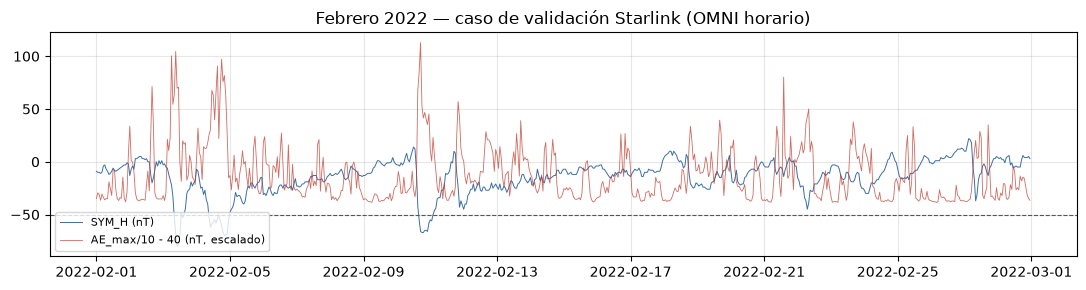

In [27]:
v = omni_idx.loc["2022-02-01":"2022-02-28", ["SYM_H", "AE_INDEX_max"]]
fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(v.index, v.SYM_H, lw=0.7, color="#3b6ea5", label="SYM_H (nT)")
ax.plot(v.index, v.AE_INDEX_max / 10 - 40, lw=0.6, color="#c0392b", alpha=0.75,
        label="AE_max/10 - 40 (nT, escalado)")
ax.axhline(-50, ls="--", lw=0.8, color="#555")
ax.set_title("Febrero 2022 — caso de validación Starlink (OMNI horario)")
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

---

## 5. Trampas de estos datos

Las que van a morder al que los use. Las dos primeras son las serias.

### 5.1 ⚠️ `BZ_GSM_max` no contiene la eyección sur

`scripts/fetch_omni.py:95` mete `BZ_GSM` en `AGG_MAX`, así que la columna
guarda el **máximo** horario de un campo cuya señal útil es la **mínima** (la
orientación sur del IMF, que es la que acopla con la magnetósfera y dispara
tormentas). El comentario del código dice lo contrario:

```python
AGG_MAX = ("BZ_GSM", "AE_INDEX", ...)   # "the southward IMF excursion"
```

Los datos confirman que la columna es un máximo y no una eyección sur:

- mediana **+1,55 nT**, percentil 95 **+6,80 nT** → casi siempre la orientación
  más *norte* de la hora
- en 15 años, **una sola** hora baja de −39 nT. Si fuera el mínimo horario,
  veríamos horas completas persistentemente en −20 nT durante tormentas grandes

In [28]:
b = omni["BZ_GSM_max"].dropna()
print("percentiles de BZ_GSM_max (nT):")
print({f"p{p}": round(float(b.quantile(p / 100)), 2) for p in [1, 5, 25, 50, 75, 95, 99]})
print()
for t in [-10, -20, -30, -39]:
    n = int((b <= t).sum())
    print(f"horas con BZ_GSM_max <= {t:4d} nT : {n:5d}  ({n / len(b) * 100:.4f}%)")
print()
print("Una eyección sur fuerte (Bz < -20 nT) durante una hora ENTERA ocurre")
print("en cada tormenta grande. Que el maximo horario caiga ahi una vez en")
print("15 años prueba que la columna no guarda esa excursion.")
print()
print("Corolario: el coupling driver del README (que usa BZ) no se puede")
print("evaluar con esta columna tal como esta. Arreglo: mover BZ_GSM a")
print("AGG_MIN y volver a bajar los años (los datos de 5 min no se guardan).")

percentiles de BZ_GSM_max (nT):
{'p1': -6.57, 'p5': -2.93, 'p25': -0.09, 'p50': 1.55, 'p75': 3.29, 'p95': 6.8, 'p99': 11.29}

horas con BZ_GSM_max <=  -10 nT :   407  (0.3265%)
horas con BZ_GSM_max <=  -20 nT :    18  (0.0144%)
horas con BZ_GSM_max <=  -30 nT :     3  (0.0024%)
horas con BZ_GSM_max <=  -39 nT :     1  (0.0008%)

Una eyección sur fuerte (Bz < -20 nT) durante una hora ENTERA ocurre
en cada tormenta grande. Que el maximo horario caiga ahi una vez en
15 años prueba que la columna no guarda esa excursion.

Corolario: el coupling driver del README (que usa BZ) no se puede
evaluar con esta columna tal como esta. Arreglo: mover BZ_GSM a
AGG_MIN y volver a bajar los años (los datos de 5 min no se guardan).


### 5.2 ⚠️ En OMNI no hay `Dst` ni `Kp`

Los índices disponibles son `SYM_H`/`SYM_D` (corriente en anillo — el
sucesor moderno de `Dst`, pero **no numéricamente comparable**) y
`AE_INDEX`/`AL_INDEX`/`AU_INDEX`. La §4.1 muestra que `SYM_H` es el mejor
proxy de Kp (−0,74), no `AE` (+0,53). Si se necesita Kp real hay que
incorporarlo de otra fuente (p. ej. GFZ Potsdam).

### 5.3 `linkedEvents` cuelga

369 `activityID` referenciados no están descargados: 280 `RBE` y 88 `MPC`
(endpoints que el collector no baja) y 1 CME de 2011 (fuera de ventana).
Cualquier join por cadena causal tiene que tolerar referencias rotas.

### 5.4 Vacío vs. null vs. centinela

- **DONKI — `""` vs. `NaN`**: `sourceLocation` y `note` llegan como cadena
  vacía, no `NaN`. `NaN` aparece solo cuando el campo no vino en el registro.
- **DONKI — IDs centinela**: un registro de `GST` (2016-02-17) tiene
  `gstID` = la **cadena literal `"none"`**, no `null`. Es la llave de join de
  las cadenas causales, así que un `fillna` o un cast ingenuo la rompe. Es el
  único caso en los 7 endpoints.
- **OMNI**: los centinelas de fill ya están convertidos a `NaN`; lo que queda
  son gaps reales de L1.
- **`CMEAnalysis`**: `tilt` y `minorHalfWidth` son 100% nulos y quedaron con
  dtype `object`, no numérico. Hay que castear explícitamente.

In [29]:
SENTINELAS = {"none", "null", "nan", "nat", "n/a", "-", ""}
print("IDs centinela por endpoint:")
for ep, d in DONKI.items():
    idc = next((c for c in d.columns if c in ("activityID", "gstID", "flrID", "sepID", "hssID")), None)
    if idc is None:
        continue
    marca = d[idc].astype(str).str.strip().str.lower().isin(SENTINELAS).sum()
    print(f"  {ep:6s} {idc:12s}: {marca}")
print()
print("DONKI — sourceLocation vacio vs NaN (CME):")
sc = DONKI["CME"]["sourceLocation"]
print(f"  vacios '': {(sc == '').sum():,}   NaN: {sc.isna().sum():,}")
print()
print("CMEAnalysis — columnas object que deberian ser numericas:")
for c in ["tilt", "minorHalfWidth", "speedMeasuredAtHeight"]:
    s = DONKI["CMEAnalysis"][c]
    print(f"  {c:24s} dtype={str(s.dtype):8s} nulos={s.isna().mean() * 100:5.1f}%")

IDs centinela por endpoint:
  CME    activityID  : 0
  GST    gstID       : 1
  FLR    flrID       : 0
  SEP    sepID       : 0
  IPS    activityID  : 0
  HSS    hssID       : 0

DONKI — sourceLocation vacio vs NaN (CME):
  vacios '': 6,444   NaN: 0

CMEAnalysis — columnas object que deberian ser numericas:
  tilt                     dtype=object   nulos=100.0%
  minorHalfWidth           dtype=object   nulos=100.0%
  speedMeasuredAtHeight    dtype=object   nulos= 54.6%


### 5.5 El ESA Anomaly Dataset no se alinea

El dataset de anomalías de ESA tiene el **eje temporal anonymizado**: la
anonimización "impide esperar anomalías en tiempos específicos, p. ej. durante
actividad solar aumentada" (paper). **Nunca** alinear contra DONKI/OMNI ni
usarlo en el análisis causal. Es benchmark, no evidencia.

---

## 6. Recetas

Cómo cargar y usar estos datos. Mismo formato que `docs/datos_omni.md` §9.

In [30]:
# Desde un script en la raiz del repo se puede usar la ruta relativa
# "data/omni/year=2022/part-00000.parquet"; aca se usa DATA porque el
# kernel corre con CWD = notebooks/.

# Un año de OMNI
omni_2022 = pd.read_parquet(DATA / "omni/year=2022/part-00000.parquet")

# El rango completo (~20 MB en RAM)
omni_all = pd.concat(
    [pd.read_parquet(f) for f in sorted(DATA.glob("omni/year=*/part-00000.parquet"))],
    ignore_index=True,
).set_index("EPOCH").sort_index()

# Tormentas: umbral de corriente en anillo, sin Kp (no existe en OMNI)
storms = omni_all[omni_all["SYM_H"] <= -50]
print(f"omni_2022: {omni_2022.shape} | storms 2012-2026: {len(storms):,} horas")

omni_2022: (8760, 46) | storms 2012-2026: 5,342 horas


In [31]:
# Un endpoint de DONKI
cme = pd.concat(
    [pd.read_parquet(f) for f in sorted(DATA.glob("donki/CME/year=*/part-00000.parquet"))],
    ignore_index=True,
)
cme["t"] = pd.to_datetime(cme["startTime"], utc=True, format="mixed")

# CMEs que DONKI marca como la analisis mas preciso
best = (
    DONKI["CMEAnalysis"]
    .query("isMostAccurate and speed > 1000")
    .assign(t=lambda d: pd.to_datetime(d.time21_5, utc=True, format="mixed"))
    .sort_values("speed", ascending=False)[["associatedCMEID", "speed", "halfAngle", "t"]]
)
print(f"CMEs > 1000 km/s: {len(best)}")
best.head(8).to_string(index=False)

CMEs > 1000 km/s: 718


'            associatedCMEID  speed  halfAngle                         t\n2024-02-12T06:36:00-CME-001 3529.0       49.0 2024-02-12 07:36:00+00:00\n2012-07-23T02:36:00-CME-001 3435.0       80.0 2012-07-23 03:30:00+00:00\n2024-02-12T06:36:00-CME-001 3180.0       42.0 2024-02-12 07:42:00+00:00\n2024-12-17T16:00:00-CME-001 3161.0       44.0 2024-12-17 16:56:00+00:00\n2025-03-21T16:00:00-CME-001 3032.0       25.0 2025-03-21 16:41:00+00:00\n2012-03-07T00:36:00-CME-001 2809.0       54.0 2012-03-07 01:38:00+00:00\n2012-07-23T02:36:00-CME-001 2800.0       65.0 2012-07-23 04:10:00+00:00\n2012-07-23T02:36:00-CME-001 2715.0       59.0 2012-07-23 03:49:00+00:00'

---

## 7. El eslabón que falta: tiempo de llegada del shock

Esta es la prueba de que las dos fuentes encajan, y el puntapé hacia el aviso
anticipado del README §6.

La velocidad del CME (`speed` en `CMEAnalysis`) más la del viento solar
(`flow_speed` en OMNI) dan el **tiempo de tránsito** del shock:

$$t_{\text{tránsito}} = \frac{1{,}496 \times 10^8 \ \text{km}}{v_{\text{CME}} - v_{\text{viento}} \ \text{(km/s)}}$$

Comparado contra el inicio real de la tormenta en OMNI, hay **dos** formas de
hacerlo, y la diferencia entre ellas es el punto entero del proyecto:

- **Ingénua**: buscar el CME más cercano en el tiempo y tomar el mínimo de
  `SYM_H` en las 120 h siguientes.
- **Causal**: seguir el `linkedEvents` de DONKI, que ya dice qué CME produjo
  qué tormenta.

In [32]:
AU_KM = 1.496e8
gst = DONKI["GST"]
cme_ids = set(DONKI["CME"]["activityID"])

# La cadena corre GST -> CME (no al reves): cada GST lista sus CME en linkedEvents.
gst2cme = {}
for gid, links in zip(gst["gstID"], gst["linked_activity_ids"]):
    if links is None or not hasattr(links, "__iter__"):
        continue
    for ref in links:
        if ref in cme_ids:
            gst2cme[ref] = gid
print(f"CMEs enlazados a una tormenta: {len(gst2cme)}")
print(f"tormentas con al menos un CME : {len(set(gst2cme.values()))} de {len(gst)}")
print()
print("Ojo con el tipo de las listas: tras pd.concat las columnas-lista de")
print("Parquet quedan como numpy.ndarray, no list. Un isinstance(x, list)")
print("falla en silencio y hace perder todas las relaciones.")

CMEs enlazados a una tormenta: 138
tormentas con al menos un CME : 94 de 186

Ojo con el tipo de las listas: tras pd.concat las columnas-lista de
Parquet quedan como numpy.ndarray, no list. Un isinstance(x, list)
falla en silencio y hace perder todas las relaciones.


In [33]:
# CMEs rapidas y precisas, con el viento solar en el momento del analisis
cand = (
    DONKI["CMEAnalysis"]
    .query("isMostAccurate and speed > 1000")
    .assign(t=lambda d: pd.to_datetime(d.time21_5, utc=True, format="mixed"))
    [["t", "speed", "associatedCMEID"]]
    .sort_values("t")
    .reset_index(drop=True)
)
viento = omni[["flow_speed"]].reset_index().sort_values("EPOCH")
cand = pd.merge_asof(
    cand, viento, left_on="t", right_on="EPOCH",
    direction="nearest", tolerance=pd.Timedelta("1h"),
)
cand = cand.dropna(subset=["flow_speed"])
cand = cand[(cand["speed"] - cand["flow_speed"]) > 0].copy()
cand["transit_h"] = AU_KM / (cand["speed"] - cand["flow_speed"]) / 3600
cand["llegada"] = cand["t"] + pd.to_timedelta(cand["transit_h"], unit="h")
cand["gstID"] = cand["associatedCMEID"].map(gst2cme)

print(f"CMEs rapidas con viento solar disponible: {len(cand)}")
print()
print("tiempo de transito Solar -> magnetosfera (horas):")
print(cand["transit_h"].describe().round(1).to_string())

CMEs rapidas con viento solar disponible: 671

tiempo de transito Solar -> magnetosfera (horas):
count    671.0
mean      52.7
std       16.8
min       13.7
25%       41.0
50%       52.3
75%       63.1
max      123.9


In [34]:
def primero(valor):
    # all_kp_times es una lista serializada; tras el concat llega como ndarray
    return valor[0] if hasattr(valor, "__iter__") and not isinstance(valor, str) else valor


gst_idx = gst.set_index("gstID")
filas = []
for _, r in cand.dropna(subset=["gstID"]).iterrows():
    inicio = pd.to_datetime(primero(gst_idx.loc[r["gstID"], "all_kp_times"]), utc=True, format="mixed")
    ventana = omni.loc[inicio - pd.Timedelta("6h") : inicio + pd.Timedelta("30h")]
    if ventana.empty:
        continue
    filas.append({
        "gstID": r["gstID"],
        "llegada_estimada": r["llegada"],
        "inicio_tormenta": inicio,
        "delta_h": (inicio - r["llegada"]).total_seconds() / 3600,
        "v_cme_km_s": r["speed"],
        "SYM_H_min": ventana["SYM_H"].min(),
        "kp_max": float(gst_idx.loc[r["gstID"], "all_kp_max"]),
    })
validacion = pd.DataFrame(filas)
print(f"CMEs rapidas enlazadas a una tormenta: {len(validacion)}")
validacion

CMEs rapidas enlazadas a una tormenta: 65


,gstID,llegada_estimada,inicio_tormenta,delta_h,v_cme_km_s,SYM_H_min,kp_max
0,2012-01-24T18:00:00-GST-001,2012-01-24 04:59:29.774977581+00:00,2012-01-24 21:00:00+00:00,16.008396,2211.0,-81.0,5.00
1,2012-03-09T03:00:00-GST-001,2012-03-07 18:39:12.552272122+00:00,2012-03-09 06:00:00+00:00,35.346513,2809.0,-149.0,7.00
2,2012-03-09T03:00:00-GST-001,2012-03-08 00:24:34.880357971+00:00,2012-03-09 06:00:00+00:00,29.590311,2200.0,-149.0,7.00
3,2012-03-09T03:00:00-GST-001,2012-03-08 07:20:29.164776098+00:00,2012-03-09 06:00:00+00:00,22.658565,1800.0,-149.0,7.00
4,2012-03-12T10:30:00-GST-001,2012-03-12 16:50:54.235775116+00:00,2012-03-12 10:30:00+00:00,-6.348399,1400.0,-67.0,6.00
...,...,...,...,...,...,...,...
60,2026-06-05T15:00:00-GST-001,2026-06-05 06:30:18.665757820+00:00,2026-06-05 18:00:00+00:00,11.494815,1220.0,-59.0,6.33
61,2026-06-05T15:00:00-GST-001,2026-06-05 14:29:49.170945422+00:00,2026-06-05 18:00:00+00:00,3.503008,1098.0,-59.0,6.33
62,2026-06-05T15:00:00-GST-001,2026-06-05 05:50:02.016001541+00:00,2026-06-05 18:00:00+00:00,12.166107,1433.0,-59.0,6.33
63,2026-06-05T15:00:00-GST-001,2026-06-05 07:04:34.068765309+00:00,2026-06-05 18:00:00+00:00,10.923870,1405.0,-59.0,6.33


In [35]:
print("== Metodo CAUSAL (linkedEvents de DONKI) ==")
print(validacion["delta_h"].describe().round(1).to_string())
print()

# El metodo ingenuo, para contraste: el CME mas rapido anterior a cada tormenta
ingenuo = []
for gid, row in gst_idx.iterrows():
    inicio = pd.to_datetime(primero(row["all_kp_times"]), utc=True, format="mixed")
    previos = cand[(cand["t"] <= inicio) & (cand["t"] >= inicio - pd.Timedelta("72h"))]
    if previos.empty:
        continue
    elegido = previos.nlargest(1, "speed").iloc[0]
    ingenuo.append((inicio - elegido["llegada"]).total_seconds() / 3600)
ingenuo = pd.Series(ingenuo)

comparacion = pd.DataFrame({
    "causal": validacion["delta_h"].abs().describe(),
    "ingenuo": ingenuo.abs().describe(),
}).round(1)
print("== |error| de la hora de llegada, en horas ==")
print(comparacion)
print()
for tol in (12, 24, 48):
    print(f"  error <= {tol:2d} h -> causal {int((validacion.delta_h.abs() <= tol).sum()):3d}/{len(validacion)}"
          f"   ingenuo {int((ingenuo.abs() <= tol).sum()):3d}/{len(ingenuo)}")

== Metodo CAUSAL (linkedEvents de DONKI) ==
count    65.0
mean      4.3
std      17.1
min     -36.2
25%      -8.2
50%       3.5
75%      16.9
max      36.2



== |error| de la hora de llegada, en horas ==
       causal  ingenuo
count    65.0     66.0
mean     14.6     19.3
std       9.7     14.0
min       1.0      0.9
25%       6.1      6.6
50%      14.1     16.9
75%      21.6     26.5
max      36.2     61.6

  error <= 12 h -> causal  27/65   ingenuo  23/66
  error <= 24 h -> causal  53/65   ingenuo  45/66
  error <= 48 h -> causal  65/65   ingenuo  63/66


**La diferencia es real pero moderada, y conviene no exagerarla.** El método
causal acierta con mediana de **14,1 h** de error contra **16,9 h** del
emparejamiento temporal, y metodos comparables por separado: 53/65 dentro de
24 h contra 45/66, y un error máximo de 36 h contra 62 h.

O sea: seguir la cadena causal de DONKI **reduce el error de aviso**, sobre
todo en la cola (los casos malos), pero no lo elimina. Tres razones
plausibles, y son el trabajo pendiente:

1. `speed` de `CMEAnalysis` es la velocidad del **CME**, no la del **shock**.
   La conversión CME→shock necesita la hora de primera aparición de la
   perturbación de choque, que este endpoint no trae.
2. Se usa el viento solar **en el momento del análisis**, no en la hora de
   llegada. Un CME rápido puede cruzar una región de alta velocidad.
3. La hora de inicio de la tormenta se toma del primer `kpIndex` reportado,
   que llega con horas de rezago y no marca el onset magnetosférico.

Lo que sí queda establecido: **la cadena causal de DONKI aporta señal
independiente del tiempo**, porque un emparejamiento puramente temporal la
empeora. Ese es el insumo que necesita el aviso anticipado del README §6.

Siguiente paso natural (pipeline §3): reemplazar `speed` por la velocidad
reportada en tiempo real por el SWPC, y cruzar estos tiempos de llegada con
`gp_history` para ver qué satélites decaen en la ventana.

---

## 8. Referencias

- [`docs/datos_omni.md`](../docs/datos_omni.md) — diccionario y trampas de OMNI
- [`docs/datos_donki.md`](../docs/datos_donki.md) — diccionario de los 7 endpoints de DONKI
- `scripts/fetch_omni.py` — colector HAPI, regla de agregación §4
- `scripts/fetch_donki.py` — colector DONKI, aplanado de registros
- Gunter's Space Page: © Gunter Dirk Krebs 1996–2026
  (https://space.skyrocket.de) — capa narrativa, no usada en las dos fuentes
  anteriores.